In [374]:
suppressPackageStartupMessages({
    library(dplyr)
    library(stringr)
    library(Biostrings)
    library(data.table)
    library(igraph)
    library(pwalign)
    library(Rsamtools)
    library(parallel)
})

source("/srv/home/mlef0011/VDARK/src/utils.r")
source("/srv/home/mlef0011/VDARK/src/dbg_assembly_igraph.r")

WD        <- "/srv/home/mlef0011/VDARK"
MINIMAP   <- "/srv/home/mlef0011/anaconda3/envs/VDARK/bin/minimap2"
REF       <- "/srv/home/mlef0011/rawdata/ref_genome/reference_genome_GRCh37.fa"
N_CORES   <- 20
K         <- 31
label     <- paste0("chr21_k", K)
COV       <- 55

KMER_MAX_FREQ <- 50
MIN_SHARED_KMERS <- 2
NORMAL_KMER_MIN_COV <- 10
FLANKING_MAX_FREQ <- 50
CLUSTER_SIZE_CAP <- 100
MIN_MEAN_WEIGHT        <- 5
MIN_ALN_SCORE          <- 30
MAX_N_SIG_KMERS_NORMAL <- 5
MAX_N_KMER_SIG         <- K 
MIN_N_KMER_SIG        <- 10


In [2]:
sample = '5dbf3203-ce73-41e4-bf9a-32fc856f73f5'
snv_path = "/srv/home/mlef0011/rawdata/PCAWG_data/TCGA/snv_mnv/5dbf3203-ce73-41e4-bf9a-32fc856f73f5.consensus.20160830.somatic.snv_mnv.vcf.gz"
snv_df = fread(snv_path, data.table=F)
snv_df = snv_df[snv_df$FILTER == "." & snv_df$`#CHROM` == 21,]
head(snv_df)

,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
10191,21,10713428,.,C,A,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.2553;repeat_masker=ALR/Alpha;t_alt_count=36;t_ref_count=105;Variant_Classification=IGR"
10192,21,10790956,.,A,G,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.2452;repeat_masker=(GAATG)n;t_alt_count=38;t_ref_count=117;Variant_Classification=IGR"
10193,21,10830301,.,A,G,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.2079;repeat_masker=(GAATG)n;t_alt_count=37;t_ref_count=141;Variant_Classification=IGR"
10194,21,10843666,.,A,T,.,.,"Callers=broad,muse;NumCallers=2;VAF=0.1967;repeat_masker=(GAATG)n;t_alt_count=24;t_ref_count=98;signature_N3;Variant_Classification=IGR"
10197,21,10995150,.,C,G,.,.,"Callers=broad,dkfz,muse,sanger;NumCallers=4;VAF=0.1667;t_alt_count=15;t_ref_count=75;Variant_Classification=Intron"
10200,21,11131058,.,C,A,.,.,"Callers=broad,muse;NumCallers=2;repeat_masker=AluSc8;Variant_Classification=IGR"


In [3]:
assembly <- function(kmers, k, kmer_freq, coverage = NULL, type = c("greedy","dbg"), mode = c("normal", "tumour")) {

    type <- match.arg(type)
    
    if(type == "greedy"){
        return(assemble_kmers(kmers, k, kmer_freq = NULL))
    } else if (type == "dbg"){
        mode <- match.arg(mode)
        out <- assemble_dbg(kmers, k = k, kmer_freq = kmer_freq,
                            coverage = coverage, mode = mode)

        if (is.null(out)) {
            return( NULL)
        }
        return(out)
    }
}

### Load data

In [4]:
load_reads <- function(r1, r2) {
    fq1 <- readDNAStringSet(r1, format = "fastq")
    fq2 <- readDNAStringSet(r2, format = "fastq")
    data.frame(
        read_ID  = c(names(fq1), names(fq2)),
        sequence = as.character(c(fq1, fq2)),
        stringsAsFactors = FALSE
    )
}

load_reads <- function(r1, r2) {
    fq1 <- readDNAStringSet(r1, format = "fastq")
    fq2 <- readDNAStringSet(r2, format = "fastq")
    data.frame(
        read_ID  = c(paste0(names(fq1), "/R1"), paste0(names(fq2), "/R2")),
        sequence = as.character(c(fq1, fq2)),
        stringsAsFactors = FALSE
    )
}


tumour_reads <- load_reads(
    file.path(WD, paste0("rawdata/reads/tumour_R1_tumour_specific_",label,"_filtered.fq")),
    file.path(WD, paste0("rawdata/reads/tumour_R2_tumour_specific_",label,"_filtered.fq"))
)

### Associate each k-mer with its original read.

In [5]:
cat(paste0("/srv/home/mlef0011/anaconda3/condabin/conda run -n VDARK python3 /srv/home/mlef0011/VDARK/src/build_read_kmer_table.py -k 31 -f /srv/home/mlef0011/VDARK/rawdata/kmer/tumour_specific_",label,"_filtered.txt -o rawdata/reads/read_kmer_association_",label,"_filtered.tsv"))

/srv/home/mlef0011/anaconda3/condabin/conda run -n VDARK python3 /srv/home/mlef0011/VDARK/src/build_read_kmer_table.py -k 31 -f /srv/home/mlef0011/VDARK/rawdata/kmer/tumour_specific_chr21_k31_filtered.txt -o rawdata/reads/read_kmer_association_chr21_k31_filtered.tsv

### Clustering reads sharing same k-mers to perfom local assembly

In [6]:
read_kmer_df <- fread(file.path(WD, paste0("rawdata/reads/read_kmer_association_",label,"_filtered.tsv")))
read_kmer_df <- read_kmer_df[, if (.N <= KMER_MAX_FREQ) .SD, by = kmer]  
head(read_kmer_df)

kmer,read_ID
<chr>,<chr>
GGAGGTCAGGAGGTCGAGACCAGCCTGGCCA,HWI-ST489:140921414:C25H8ACXX:4:1207:16800:42002/R1
GGAGGTCAGGAGGTCGAGACCAGCCTGGCCA,HWI-ST489:140921414:C25H8ACXX:3:1109:20463:88160/R1
GGAGGTCAGGAGGTCGAGACCAGCCTGGCCA,HWI-ST489:140921414:C25H8ACXX:2:2311:2064:28434/R1
GGAGGTCAGGAGGTCGAGACCAGCCTGGCCA,HWI-ST489:140921414:C25H8ACXX:3:2101:16770:25061/R1
GGAGGTCAGGAGGTCGAGACCAGCCTGGCCA,HWI-ST489:140921414:C25H8ACXX:5:2309:16031:100429/R2
ACCTCACCCTCACACTAATCCAACCCTAACC,HWI-ST489:140921414:C25H8ACXX:2:2307:7116:85808/R1


In [84]:
read_kmer_df[read_kmer_df$kmer == "TGAGAGAAACAGAGCCACCTTTTTCCATAAA",]

kmer,read_ID
<chr>,<chr>
TGAGAGAAACAGAGCCACCTTTTTCCATAAA,HWI-ST489:140921414:C25H8ACXX:3:1206:11372:2820/R1
TGAGAGAAACAGAGCCACCTTTTTCCATAAA,HWI-ST489:140921414:C25H8ACXX:1:2116:1728:24624/R1
TGAGAGAAACAGAGCCACCTTTTTCCATAAA,HWI-ST489:140921414:C25H8ACXX:2:1108:8424:66886/R1


In [7]:
read_kmer_df <- fread(file.path(WD, paste0("rawdata/reads/read_kmer_association_",label,"_filtered.tsv")))
read_kmer_df <- read_kmer_df[, if (.N <= KMER_MAX_FREQ) .SD, by = kmer]  

pairs <- read_kmer_df[, {
    ids <- read_ID
    if (length(ids) >= 2) {
        idx <- combn(length(ids), 2)
        data.table(read_ID.x = ids[idx[1,]], read_ID.y = ids[idx[2,]])
    }
}, by = kmer][, .(weight = .N), by = .(read_ID.x, read_ID.y)]

pairs <- pairs[weight >= MIN_SHARED_KMERS]
                           
G        <- graph_from_data_frame(pairs, directed = FALSE)
E(G)$weight <- pairs$weight
clusters <- get("components", envir = asNamespace("igraph"))(G)

big_clusters <- which(clusters$csize > CLUSTER_SIZE_CAP)
log_msg(length(big_clusters), " cluster(s) excluded (>", CLUSTER_SIZE_CAP, " reads) — likely repetitive")
valid_clusters <- setdiff(seq_len(clusters$no), big_clusters)
# ── Filtre mean_weight, appliqué une fois pour tout le run ───────────────────
all_ids             <- seq_len(clusters$no)
mw_all              <- mean_weight_dt[.(all_ids), mean_weight]  # NA = pas dans pairs (cluster isolé/faible signal)
low_weight_clusters <- all_ids[is.na(mw_all) | mw_all < MIN_MEAN_WEIGHT]

log_msg(length(low_weight_clusters), " cluster(s) excluded (mean_weight < ", MIN_MEAN_WEIGHT, ")")

valid_clusters <- setdiff(all_ids, union(big_clusters, low_weight_clusters))
log_msg(length(valid_clusters), " valid cluster(s) after all pre-filters")

# ── Pre-split read_kmer_df by cluster, once ──────────────────────────────────
read_kmer_df[, cluster_ID := cluster_of[read_ID]]
kmer_by_cluster <- split(read_kmer_df[!is.na(cluster_ID)], by = "cluster_ID")

[10:59:08] 6 cluster(s) excluded (>100 reads) <U+2014> likely repetitive



ERROR: Error: object 'mean_weight_dt' not found


In [ ]:
cluster_of <- clusters$membership   # named int vector: names = read_ID

mean_weight_dt <- pairs[, cluster_ID := cluster_of[read_ID.x]
                        ][, .(mean_weight = mean(weight), n_edges = .N),
                          by = cluster_ID]
setkey(mean_weight_dt, cluster_ID)

# Résumé numérique
summary(mean_weight_dt$mean_weight)

# Distribution avec ton seuil actuel en repère
library(ggplot2)
ggplot(mean_weight_dt, aes(x = mean_weight)) +
    geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
    geom_vline(xintercept = MIN_MEAN_WEIGHT, color = "red", linetype = "dashed") +
    geom_vline(xintercept = MIN_SHARED_KMERS, color = "grey40", linetype = "dotted") +
    labs(title = "Distribution de mean_weight par cluster",
         subtitle = paste0("Ligne rouge = MIN_MEAN_WEIGHT (", MIN_MEAN_WEIGHT,
                           ") | Ligne grise = MIN_SHARED_KMERS (", MIN_SHARED_KMERS, ")"),
         x = "mean_weight", y = "nombre de clusters")

cluster_sizes <- data.table(cluster_ID = seq_len(clusters$no), size = clusters$csize)

summary(cluster_sizes$size)

ggplot(cluster_sizes, aes(x = size)) +
    geom_histogram(bins = 50, fill = "steelblue", color = "white") +
    geom_vline(xintercept = CLUSTER_SIZE_CAP, color = "red", linetype = "dashed") +
    scale_x_log10() +
    labs(title = "Distribution de la taille des clusters",
         subtitle = paste0("Ligne rouge = CLUSTER_SIZE_CAP (", CLUSTER_SIZE_CAP, ")"),
         x = "nombre de reads dans le cluster", y = "nombre de clusters")

In [8]:
Read name = HWI-ST489:140921414:C25H8ACXX:3:1206:11372:2820
Sample = 5dbf3203-ce73-41e4-bf9a-32fc856f73f5
Library = WGS:WUGSC:H_LS-GI-A2C9-01A-11D-A21Q-09-lg1-lib1b
Read group = WUGSC:2893192439
Read length = 100bp
Flags = 99
----------------------
Mapping = Primary @ MAPQ 60
Reference span = chr21:36,048,162-36,048,261 (+) = 100bp
Cigar = 100M
Clipping = None
----------------------
Mate is mapped = yes
Mate start = chr21:36048462 (-)
Insert size = 401
First in pair
Pair orientation = F1R2
----------------------
NM = 1
AS = 95
XS = 22
Hidden tags: MD, RGLocation = chr21:36,048,203
Base = A @ QV 41


ERROR: Error in parse(text = input): <text>:1:6: unexpected symbol
1: Read name
         ^


In [210]:
kmer = "'AATTTCTAAAAATAAATTGCTATTCAATGG"
nchar(kmer)
kmer
as.character(reverseComplement(DNAString(kmer)))

[1] 31

[1] "'AATTTCTAAAAATAAATTGCTATTCAATGG"

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'reverseComplement': key 39 (char ''') not in lookup table


In [394]:
read_ID <- "HWI-ST489:140921414:C25H8ACXX:3:1206:11372:2820/R1"
read_ID %in% read_kmer_df$read_ID
cluster_ID <- clusters$membership[read_ID]
cluster_ID <- 13835

[1] TRUE

[1] 5

[1] 8

[1]  9  8  9 17  8  4  4  4

[1] "HWI-ST489:140921414:C25H8ACXX:4:1116:10864:81604/R1"
[2] "HWI-ST489:140921414:C25H8ACXX:4:2108:10898:30538/R1"
[3] "HWI-ST489:140921414:C25H8ACXX:2:1216:12377:34724/R1"
[4] "HWI-ST489:140921414:C25H8ACXX:2:2212:7195:17252/R1" 
[5] "HWI-ST489:140921414:C25H8ACXX:3:1303:10412:7616/R2"

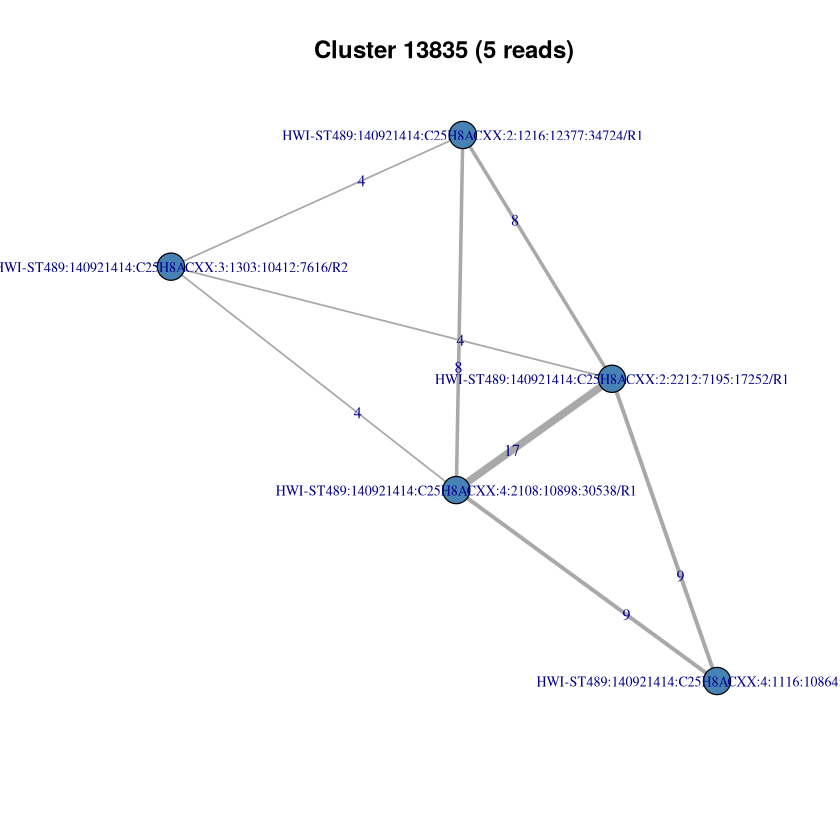

In [395]:
reads_in <- names(clusters$membership)[clusters$membership == cluster_ID]
subG     <- induced_subgraph(G, vids = reads_in)

# Vérif rapide
vcount(subG)  # nombre de reads (nœuds)
ecount(subG)  # nombre d'arêtes
E(subG)$weight
vertex_labels <- V(subG)$name
vertex_labels
plot(subG,
     edge.label       = E(subG)$weight,
     edge.width       = E(subG)$weight / max(E(subG)$weight) * 6,
     edge.label.cex   = 0.8,
     vertex.size      = 10,
     vertex.label     = vertex_labels,
     vertex.label.cex = 0.7,
     vertex.color     = "steelblue",
     layout           = layout_with_fr(subG),
     main             = paste0("Cluster ", cluster_ID, " (", vcount(subG), " reads)"))

In [396]:
reads_in <- names(clusters$membership)[clusters$membership == cluster_ID]
subG     <- induced_subgraph(G, vids = reads_in)
articulation_points(subG)

+ 0/5 vertices, named, from 7e80dd2:

In [397]:
subclusters <- inspect_and_split_cluster(cluster_ID, G, clusters)

Reads: 5 | Edges: 8 | Points d'articulation: 0 
Communaut<c3><a9>s Leiden: 1 | modularit<c3><a9>: NA 
-> Pas de split fiable, cluster conserv<c3><a9> tel quel.


In [398]:
logs <- character(0)
buf  <- function(...) logs <<- c(logs, paste0("[", format(Sys.time(), "%H:%M:%S"), "] ", ...))
k = K

### Construct tumor contig

In [399]:
tmp_cl         <- file.path(WD, "tmp", cluster_ID)
dir.create(tmp_cl, showWarnings = FALSE, recursive = TRUE)

reads_in  <- names(clusters$membership)[clusters$membership == cluster_ID]
t0 <- Sys.time()
kmers_sig <- unique(read_kmer_df$kmer[read_kmer_df$read_ID %in% reads_in])
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

  filtrage read_kmer_df:  0.037 s

In [400]:
t0 <- Sys.time()
tmp_cl         <- file.path(WD, "tmp", cluster_ID)
dir.create(tmp_cl, showWarnings = FALSE, recursive = TRUE)

reads_in  <- names(clusters$membership)[clusters$membership == cluster_ID]
kmers_sig <- unique(read_kmer_df$kmer[read_kmer_df$read_ID %in% reads_in])
all_kmers <- unique(unlist(lapply(
    tumour_reads$sequence[tumour_reads$read_ID %in% reads_in], function(seq) get_kmers(seq,K)
)))
cat("  ", length(reads_in), " reads | ", length(kmers_sig), " specific k-mers")

sig_counts <- read_kmer_df[read_ID %in% reads_in, .N, by = kmer]
kmer_freq  <- setNames(sig_counts$N, sig_counts$kmer)
asm_t <- assembly(kmers = kmers_sig, k = k, kmer_freq = kmer_freq, coverage = COV , type = "dbg", mode = "tumour")
contig_tumour <- asm_t$contigs

cat("  Tumour contig: ", nchar(contig_tumour[1]), " bp")
contig_tumour
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

   5  reads |  18  specific k-mers  Tumour contig:  47  bp

[1] "AAAAAAAAAAAAAAAAAAAAAAAGAAATTCGTTTAGCTTGCTAAGAG"
[2] "CTCTTAGCAAGCTAAACGAATTTCTTTTTTTTTTTTTTTTTTTTTTT"

  filtrage read_kmer_df:  0.512 s

In [401]:
kmers_sig

[1] "AAACAAAAAAAAAAAAAAAGAAAAAAAAAAA" "AAAAAAAAAAAAAAAAAGAAATTCGTTTAGC"
 [3] "AAAAAAAAAAAAAAAAAAAAGAAATTCGTTT" "AAAAAAAAAAAAAAAAAAAAAAGAAATTCGT"
 [5] "AAAAAAAAAAAAAAAAAAAAAAAGAAATTCG" "AAAAAAAAAAAAAAAAAAAGAAATTCGTTTA"
 [7] "AAAAAAAAAAAAAAAAAAGAAATTCGTTTAG" "AAAAAAAAAAAAAAAAGAAATTCGTTTAGCT"
 [9] "AAAAAAAAAAAAAAAGAAATTCGTTTAGCTT" "AAAAAAAAAAAAAAAAAAAAAGAAATTCGTT"
[11] "AAAAAAAAAAGAAATTCGTTTAGCTTGCTAA" "AAAAAAAAAAAAAAGAAATTCGTTTAGCTTG"
[13] "AAAAAAAAGAAATTCGTTTAGCTTGCTAAGA" "AAAAAAAGAAATTCGTTTAGCTTGCTAAGAG"
[15] "AAAAAAAAAAAGAAATTCGTTTAGCTTGCTA" "AAAAAAAAAAAAGAAATTCGTTTAGCTTGCT"
[17] "AAAAAAAAAGAAATTCGTTTAGCTTGCTAAG" "AAAAAAAAAAAAAGAAATTCGTTTAGCTTGC"

### Fetch normal reads via flanking k-mers 


In [402]:
t0 <- Sys.time()
flanking_kmers <- setdiff(all_kmers, kmers_sig)
flanking_kmers <- flanking_kmers[grepl("^[ACGT]+$", flanking_kmers)]

flanking_fa <- file.path(tmp_cl,
    paste0("flanking_", cluster_ID, "_", label, ".fa"))
kmc_db      <- file.path(tmp_cl,
    paste0("flanking_kmc_", label, cluster_ID))

writeLines(paste0(">k_", seq_along(flanking_kmers), "\n", flanking_kmers),
           flanking_fa)

system(paste(KMC, paste0("-k", K), "-t1 -ci1 -fm",
         flanking_fa, kmc_db, tmp_cl),
       ignore.stdout = TRUE, ignore.stderr = TRUE)

fq_R1_out <- file.path(tmp_cl,
    paste0("normal_R1_locus_", cluster_ID, "_", label, ".fq"))
fq_R2_out <- file.path(tmp_cl,
    paste0("normal_R2_locus_", cluster_ID, "_", label, ".fq"))

NORMAL_R1 <- file.path(WD, "rawdata/reads/normal_chr21_R1.fq")
NORMAL_R2 <- file.path(WD, "rawdata/reads/normal_chr21_R2.fq")

tsh <- max(5, min(50, round(min(120, length(flanking_kmers)) * 0.25)))
tsh

system(paste(KMC_TOOLS, "-t1", "filter", kmc_db, "-ci1",
             NORMAL_R1, paste0("-ci",tsh), fq_R1_out),
       ignore.stdout = TRUE, ignore.stderr = TRUE)
system(paste(KMC_TOOLS, "-t1", "filter", kmc_db, "-ci1",
             NORMAL_R2, paste0("-ci",tsh), fq_R2_out),
       ignore.stdout = TRUE, ignore.stderr = TRUE)


normal_df <- tryCatch(
    load_reads(fq_R1_out, fq_R2_out),
    error = function(e) data.frame(read_ID = character(),
                                   sequence = character())
)

if (nrow(normal_df) == 0) {
    buf("  No normal reads at locus -- skipping")
    message(paste(logs, collapse = "\n")); return(NULL)
}
cat("  Normal reads retained: ", nrow(normal_df))
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

[1] 30

  Normal reads retained:  33  filtrage read_kmer_df:  44.441 s

In [403]:
t0 <- Sys.time()
normal_df$n_sig_kmers <- vapply(
    normal_df$sequence,
    function(seq) sum(get_kmers(seq, K) %in% get_kmers(contig_tumour[1],K) ),
    integer(1)
)

n_sig_kmers_in_normal <- sum(normal_df$n_sig_kmers)
n_sig_kmers_in_normal
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

[1] 0

  filtrage read_kmer_df:  0.225 s

### Assemble normal contig

In [404]:
t0 <- Sys.time()
kmer_counts <- table(unlist(lapply(normal_df$sequence, get_kmers)))
#NORMAL_KMER_MIN_COV = mean(kmer_counts)
NORMAL_KMER_MIN_COV = 10
NORMAL_KMER_MIN_COV
cat("  Normal k-mers with cov>=", NORMAL_KMER_MIN_COV, ": ",
    sum(kmer_counts >= NORMAL_KMER_MIN_COV), " / ", length(kmer_counts))
kmer_to_assemble <- names(kmer_counts[kmer_counts >= NORMAL_KMER_MIN_COV])

if (length(kmer_to_assemble) == 0) {
    buf("  No k-mer with sufficient coverage in normal -- skipping")
    message(paste(logs, collapse = "\n")); return(NULL)
}

kmer_freq_vec <- kmer_counts[kmer_counts >= NORMAL_KMER_MIN_COV]
asm_n <- assembly(kmers = kmer_to_assemble, k = k, kmer_freq = kmer_freq_vec, coverage = COV, type = "dbg",
                      mode = "normal")
contig_normal     <- asm_n$contigs
normal_bubbles_df <- asm_n$bubbles    # NULL when ASSEMBLER == "greedy"

if (is.null(contig_normal) || nchar(contig_normal[1]) < K) {
    buf("  Normal contig too short -- skipping")
    message(paste(logs, collapse = "\n")); return(NULL)
}

cat("\n  Normal contig: ", nchar(contig_normal[1]), " bp")
contig_normal
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

[1] 10

  Normal k-mers with cov>= 10 :  109  /  449
  Normal contig:  104  bp

[1] "ATTCAGAAAAATCTTTAAGAATTCAAAATCCATTCATGATTTAAAAAAAAAAACTCTTAGCAAGCTAAACGAATTTCTTTTTTCTTTCTTTCTTTTTTTTTTTT"
[2] "AAAAAAAAAAAAGAAAGAAAGAAAAAAGAAATTCGTTTAGCTTGCTAAGAGTTTTTTTTTTTAAATCATGAATGGATTTTGAATTCTTAAAGATTTTTCTGAAT"

  filtrage read_kmer_df:  2.016 s

In [405]:
t0 <- Sys.time()
aln_result <- best_alignment(contig_normal, contig_tumour)
aln        <- aln_result$alignment
normal_rc  <- aln_result$normal_rc
aln_score  <- score(aln)
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

  filtrage read_kmer_df:  0.053 s

In [406]:
pat  <- strsplit(as.character(pattern(aln)), "")[[1]]
sub_ <- strsplit(as.character(subject(aln)), "")[[1]]
diff <- ifelse(pat == sub_, ".", "*")
print(paste0("  --- Alignment cluster ", cluster_ID, " ---"))
print(paste0("  Normal: ", paste(pat,  collapse = "")))
print(paste0("          ", paste(diff, collapse = "")))
print(paste0("  Tumour: ", paste(sub_, collapse = "")))
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

[1] "  --- Alignment cluster 13835 ---"
[1] "  Normal: CTCTTAGCAAGCTAAACGAATTTCTTTTTTCTTTCTTTCTTTTTTTT"
[1] "          ..............................*...*...*........"
[1] "  Tumour: CTCTTAGCAAGCTAAACGAATTTCTTTTTTTTTTTTTTTTTTTTTTT"
  filtrage read_kmer_df:  0.095 s

In [407]:
t0 <- Sys.time()
mm <- mismatchTable(aln)
nrow(mm)
contig_strand <- if (normal_rc) contig_normal[2] else contig_normal[1]
contig_strand
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

[1] 3

[1] "ATTCAGAAAAATCTTTAAGAATTCAAAATCCATTCATGATTTAAAAAAAAAAACTCTTAGCAAGCTAAACGAATTTCTTTTTTCTTTCTTTCTTTTTTTTTTTT"

  filtrage read_kmer_df:  0.026 s

In [408]:
t0 <- Sys.time()
# ── Germline filter — STAGE 1: bubbles (free, DBG only) ──────────────────
bubble_germline <- filter_germline_bubbles(
    mm, contig_strand, normal_bubbles_df, normal_rc, buf = buf
)
mm_for_kmc <- mm[!bubble_germline, ]

if (nrow(mm_for_kmc) == 0L) {
    cat("  All mismatches are bubble-germline -- no somatic")
}
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

  filtrage read_kmer_df:  0.003 s

In [409]:
mm_for_kmc

,PatternId,PatternStart,PatternEnd,PatternSubstring,SubjectStart,SubjectEnd,SubjectSubstring
,<int>,<int>,<int>,<chr>,<int>,<int>,<chr>
1,1,84,84,C,31,31,T
2,1,88,88,C,35,35,T
3,1,92,92,C,39,39,T


In [410]:
mm = mm_for_kmc
contig_strand = contig_strand
normal_seqs = normal_df$sequence
k = 31
threshold = 10

reads_dna <- DNAStringSet(normal_seqs)
i = 2

pos <- mm$PatternStart[i]
seq <- contig_strand
if (pos < 1 || pos > nchar(seq)) 
    return(FALSE)
if (substr(seq, pos, pos) != as.character(mm$PatternSubstring[i])) 
    return(FALSE)
substr(seq, pos, pos) <- as.character(mm$SubjectSubstring[i])
s_min <- max(1, pos - k + 1)
s_max <- min(pos, nchar(seq) - k + 1)
mut_kmers <- substring(seq, s_min:s_max, (s_min:s_max) + 
    k - 1)
rc_mut <- as.character(reverseComplement(DNAStringSet(mut_kmers)))
pdict <- PDict(unique(c(mut_kmers, rc_mut)))
n_reads <- sum(colSums(vcountPDict(pdict, reads_dna)) > 
    threshold)
colSums(vcountPDict(pdict, reads_dna))
n_reads

[1] 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

[1] 0

In [411]:
t0 <- Sys.time()
# ── Germline filter — STAGE 2: k-mer presence in normal reads ────────────

germline_kmc <- is_germline(mm_for_kmc, contig_strand,
                            normal_df$sequence,
                            k = K, threshold = 10, buf = buf)

germline_kmc
germline                  <- rep(TRUE, nrow(mm))
germline[!bubble_germline] <- germline_kmc
mm_somatic                <- mm[!germline, ]

if (nrow(mm_somatic) == 0) {
    cat("  No somatic variants (all germline)")
}
cat("  Somatic SNV(s): ", nrow(mm_somatic),
    "(", sum(bubble_germline), " germline via bubbles, ",
    sum(germline_kmc), " via k-mer presence)")
t1 <- Sys.time()
cat("  filtrage read_kmer_df: ", round(as.numeric(t1 - t0, units="secs"), 3), "s")

[1] FALSE FALSE FALSE

  Somatic SNV(s):  3 ( 0  germline via bubbles,  0  via k-mer presence)  filtrage read_kmer_df:  0.343 s

In [260]:
all_tumour_at_locus <- extract_tumour_reads_at_locus(kmc_db, tmp_cl)
vaf_df <- estimate_vaf(mm_somatic, contig_strand, all_tumour_at_locus, k = K)
p_value <- pbinom(3 - 1, 10, 0.005, lower.tail = FALSE)
is_true_mutation <- p_value < 0.001  # seuil classique

In [155]:
p_value <- pbinom(3 - 1, 10, 0.005, lower.tail = FALSE)
is_true_mutation <- p_value < 0.001  # seuil classique

n_alt,n_ref,vaf
<int>,<int>,<dbl>
3,137,0.02142857


In [167]:
# ε = taux d'erreur de séquençage attendu (Illumina typique : 0.001-0.005)
p_value <- pbinom(3 - 1, 10, 0.005, lower.tail = FALSE)
is_true_mutation <- p_value < 0.001  # seuil classique
is_true_mutation

[1] TRUE

In [218]:
writeLines(c(">contig_normal1", contig_normal[1]), 
           "/srv/home/mlef0011/VDARK/test/contigs_normal.fa")

In [167]:
# --- Lire le SAM ---
sam <- read.table("/srv/home/mlef0011/VDARK/test/contigs_normal_aln.sam", 
                  sep="\t", comment.char="@", fill=TRUE)
# Flag du read
flag <- sam[1, 2]
is_reverse <- bitwAnd(flag, 16) != 0  # TRUE si brin reverse
is_reverse
chrom <- sam[1, 3]
pos   <- sam[1, 4]  # position de début du contig sur le génome
contig = sam[1, 10]
# --- Boucle sur les mutations détectées ---
# Parser le soft-clip depuis le CIGAR
cigar <- as.character(sam[1, 6])

# Soft-clip gauche (S) ou hard-clip gauche (H)
left_clip <- 0
m <- regmatches(cigar, regexpr("^([0-9]+)[SH]", cigar))
if (length(m) > 0) left_clip <- as.integer(sub("[SH]", "", m))

# Soft-clip droit (S) ou hard-clip droit (H)
right_clip <- 0
m <- regmatches(cigar, regexpr("([0-9]+)[SH]$", cigar))
if (length(m) > 0) right_clip <- as.integer(sub("[SH]", "", m))
for (i in seq_len(nrow(mm_somatic))) {
    
    # Position dans le contig complet (pattern(best_aln) commence après le soft-clip)
    pos_in_contig <- mm_somatic$PatternStart[i]
    
    # Décalage : pos SAM = position génomique de la première base MAPPÉE
    # donc on soustrait le soft-clip pour avoir la position de la base 1 du contig
    pos_mut_genome <- if (is_reverse) {
        pos + nchar(as.character(contig)) - right_clip - pos_in_contig
    } else {
        pos - left_clip + pos_in_contig - 1
    }
    
    snv_ref <- as.character(mm_somatic$PatternSubstring[i])
    snv_alt <- as.character(mm_somatic$SubjectSubstring[i])
    
    if (is_reverse) {
        snv_ref <- as.character(reverseComplement(DNAString(snv_ref)))
        snv_alt <- as.character(reverseComplement(DNAString(snv_alt)))
    }
    
    cat("Chromosome :", as.character(chrom),
        "| Position :", pos_mut_genome,
        "| SNV :", snv_ref, "->", snv_alt, "\n")
}


[1] FALSE

Chromosome : 21 | Position : 10830301 | SNV : A -> G 
